# GeoFatigue Dataset - Getting Started

This notebook demonstrates how to load and explore the GeoFatigue dataset using the `geofatigue` Python package.

## Overview

The GeoFatigue dataset contains multimodal data from 40 participants performing manual material handling tasks:

1. **Physiological Data**: Wearable sensor data (accelerometer, gyroscope, EDA, BVP, temperature, steps)
2. **Contextual Sensing**: Smartphone sensors (IMU, GPS, pressure, magnetometer, sound)
3. **Spatial Layout**: GeoJSON boundaries of the experiment site
4. **Metadata**: Session information and participant demographics

In [1]:
# Import required libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from dotenv import load_dotenv

# Make the `geofatigue` package importable regardless of the kernel's working
# directory (this notebook is not pip-installed; it's run in-place, and
# Jupyter sets cwd to the notebook's own folder rather than the repo root).
repo_root = Path.cwd()
while not (repo_root / 'geofatigue').is_dir() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from geofatigue.loaders import (
    load_session_metadata,
    load_demographics,
    load_avro_physiological_data,
    load_contextual_sensing_data,
    load_spatial_layout
)

from geofatigue.loaders.physiological import (
    convert_adc_to_physical,
    calculate_heart_rate_from_peaks
)

from geofatigue.loaders.contextual import extract_gps_trajectory

from geofatigue.loaders.spatial import (
    load_all_spatial_layouts,
    identify_participant_location
)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Loading Metadata

First, let's load the session metadata and participant demographics.

In [2]:
load_dotenv()  # reads .env (copy .env.template → .env and fill in your paths)

METADATA_PATH = os.environ.get('METADATA_PATH')
if not METADATA_PATH:
    raise EnvironmentError("METADATA_PATH not set — copy .env.template to .env and fill in your paths")

# Load session metadata
session_metadata = load_session_metadata(f'{METADATA_PATH}/session_metadata.json')
print(f"Loaded session data for {len(session_metadata)} participants")

# Load demographics
demographics = load_demographics(f'{METADATA_PATH}/demographics.csv')
print(f"\nParticipant demographics:")
demographics.head()

Loaded session data for 40 participants

Participant demographics:


,age,weight,height,gender
id,,,,
p0,26,99,180,M
p1,42,81,180,M
p2,25,65,162,F
p3,30,46,158,F
p4,26,72,180,M


Demographics Summary:
Total participants: 40
Age range: 18-44 years
Mean age: 27.8 ± 7.8 years

Gender distribution:
gender
M    20
F    20
Name: count, dtype: int64


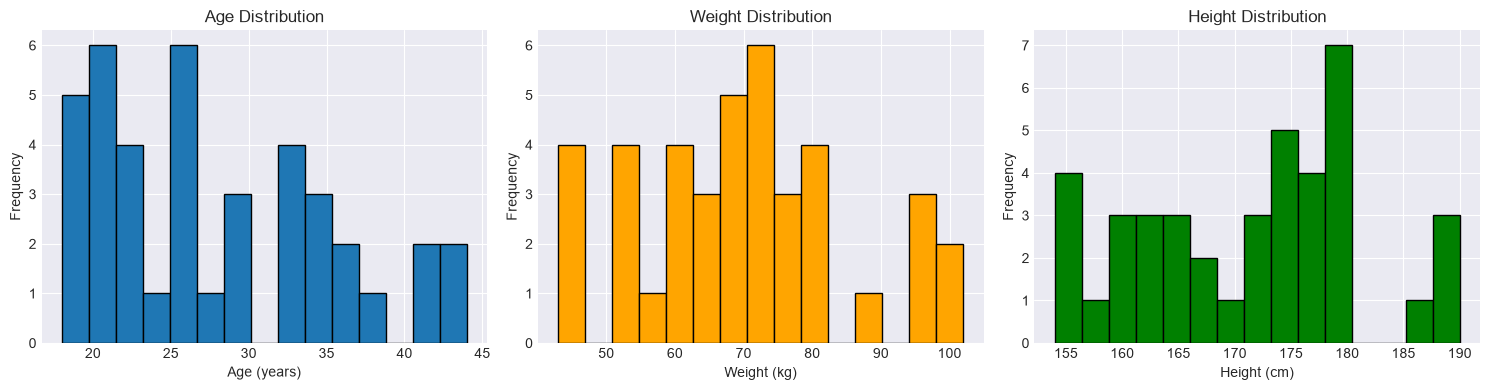

In [3]:
# Explore demographic statistics
print("Demographics Summary:")
print(f"Total participants: {len(demographics)}")
print(f"Age range: {demographics['age'].min()}-{demographics['age'].max()} years")
print(f"Mean age: {demographics['age'].mean():.1f} ± {demographics['age'].std():.1f} years")
print(f"\nGender distribution:")
print(demographics['gender'].value_counts())

# Visualize demographics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age distribution
axes[0].hist(demographics['age'], bins=15, edgecolor='black')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution')

# Weight distribution
axes[1].hist(demographics['weight'], bins=15, edgecolor='black', color='orange')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Weight Distribution')

# Height distribution
axes[2].hist(demographics['height'], bins=15, edgecolor='black', color='green')
axes[2].set_xlabel('Height (cm)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Height Distribution')

plt.tight_layout()
plt.show()

In [4]:
# Explore a specific participant
participant_id = 'p1'

print(f"Participant {participant_id}:")
print(f"Demographics: {demographics.loc[participant_id].to_dict()}")
print(f"\nNumber of sessions: {len(session_metadata[participant_id])}")
print(f"\nSession details:")
for i, session in enumerate(session_metadata[participant_id]):
    print(f"  Session {i+1}:")
    print(f"    Start: {session['start_time']}")
    print(f"    End: {session['end_time']}")
    print(f"    Tasks: {[task['label'] for task in session['tasks']]}")
    print(f"    Baseline sleep: {session['baseline']['total_sleep_hours']} hours")

Participant p1:
Demographics: {'age': 42, 'weight': 81, 'height': 180, 'gender': 'M'}

Number of sessions: 1

Session details:
  Session 1:
    Start: 2025-06-04T15:43:00.000Z
    End: 2025-06-04T17:10:00.000Z
    Tasks: ['flat_trail', 'stairs', 'ramp']
    Baseline sleep: 7.0 hours


## 2. Loading Physiological Data

Now let's load and explore physiological sensor data from an AVRO file.

In [5]:
from pathlib import Path

PHYS_DATA_PATH = os.environ.get('PHYS_DATA_PATH')
if not PHYS_DATA_PATH:
    raise EnvironmentError("PHYS_DATA_PATH not set — copy .env.template to .env and fill in your paths")

phys_root = Path(PHYS_DATA_PATH)

# Participant folders are named '{participant_id}-{device_id}' inside date-named folders.
# Glob across all date folders to find every AVRO file belonging to this participant.
avro_files = sorted(phys_root.glob(f'*/{participant_id}-*/raw_data/v6/*.avro'))

if not avro_files:
    raise FileNotFoundError(
        f"No AVRO files found for '{participant_id}' under {phys_root}. "
        "Check that PHYS_DATA_PATH points to the root physiological data folder."
    )

print(f"Found {len(avro_files)} AVRO file(s) for {participant_id}")
print(f"Loading first file: {avro_files[0].name}")

phys_data = load_avro_physiological_data(avro_files[0])

print("\nAvailable sensors:")
for sensor_name in phys_data.keys():
    print(f"  - {sensor_name}")

Found 12 AVRO file(s) for p1
Loading first file: 1-1-p1_1748992650.avro

Available sensors:
  - accelerometer
  - eda
  - temperature
  - bvp
  - systolic_peaks
  - steps


Accelerometer:
  Sampling frequency: 63.999427795410156 Hz
  Total samples across all files: 710016
  Session window: 2025-06-04T15:43:00.000Z to 2025-06-04T17:10:00.000Z
  Samples within session: 334080 / 710016


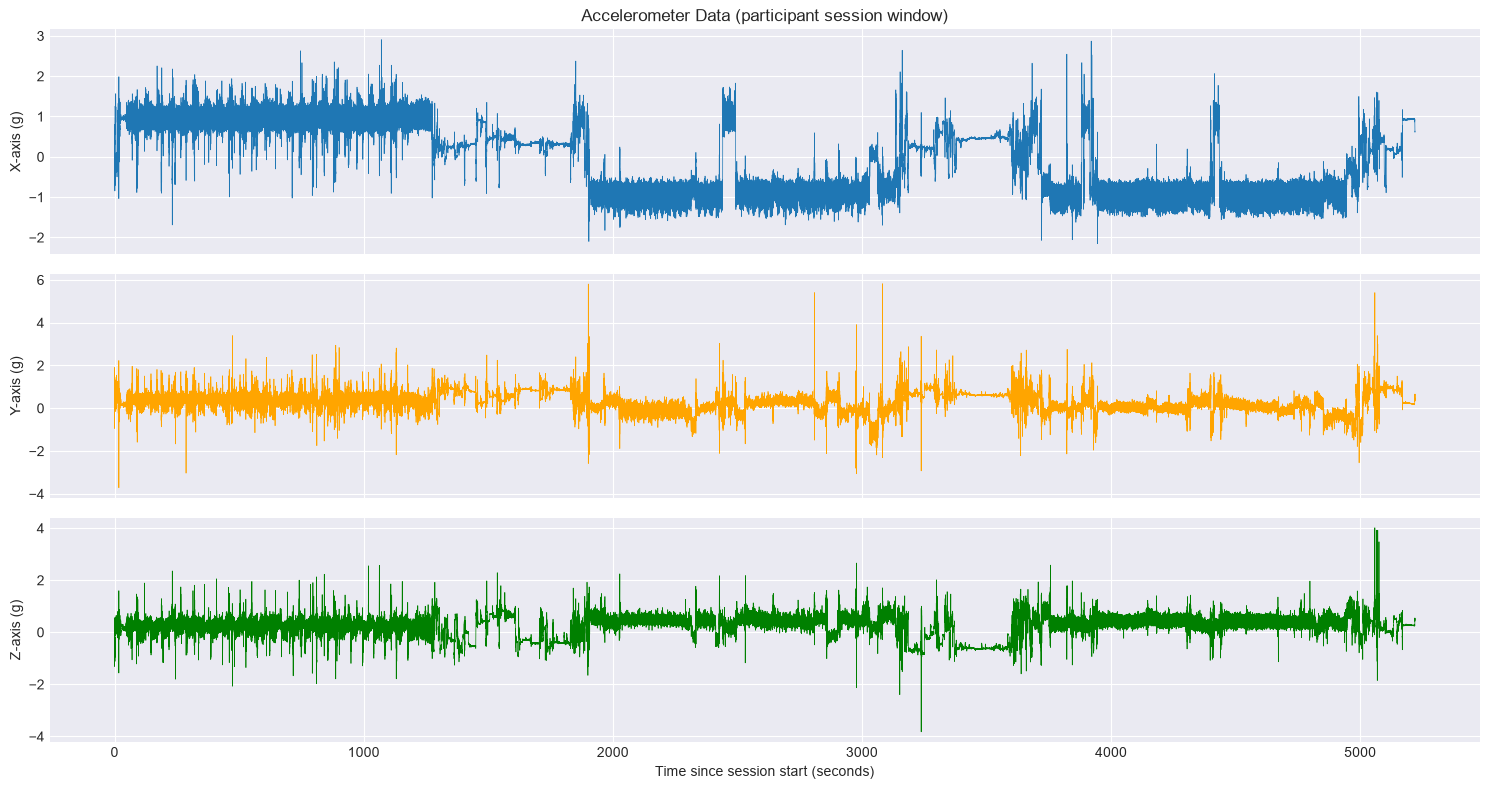

In [ ]:
# Explore accelerometer data across the participant's full session
#
# load_participant_signals merges every AVRO file for this
# participant so we can reliably slice out the actual session window.
from geofatigue.loaders.physiological import load_participant_signals

full_signals = load_participant_signals(participant_id, phys_root)
acc = full_signals['accelerometer']
print(f"Accelerometer:")
print(f"  Sampling frequency: {acc['sampling_frequency']} Hz")
print(f"  Total samples across all files: {len(acc['x'])}")

# Convert from ADC counts to g
acc_x_g = convert_adc_to_physical(acc['x'], acc['conversion_params'])
acc_y_g = convert_adc_to_physical(acc['y'], acc['conversion_params'])
acc_z_g = convert_adc_to_physical(acc['z'], acc['conversion_params'])

# Restrict to the participant's session window from the metadata.
session = min(session_metadata[participant_id], key=lambda s: s['start_time'])
session_start_us = pd.Timestamp(session['start_time']).value // 1_000
session_end_us = pd.Timestamp(session['end_time']).value // 1_000

session_mask = (acc['timestamps'] >= session_start_us) & (acc['timestamps'] <= session_end_us)
acc_timestamps = acc['timestamps'][session_mask]
acc_x_g = acc_x_g[session_mask]
acc_y_g = acc_y_g[session_mask]
acc_z_g = acc_z_g[session_mask]

print(f"  Session window: {session['start_time']} to {session['end_time']}")
print(f"  Samples within session: {session_mask.sum()} / {len(session_mask)}")

# Plot accelerometer data (session window only)
fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

time_acc = (acc_timestamps - session_start_us) / 1e6  # Seconds since session start

axes[0].plot(time_acc, acc_x_g, linewidth=0.5)
axes[0].set_ylabel('X-axis (g)')
axes[0].set_title('Accelerometer Data (participant session window)')

axes[1].plot(time_acc, acc_y_g, linewidth=0.5, color='orange')
axes[1].set_ylabel('Y-axis (g)')

axes[2].plot(time_acc, acc_z_g, linewidth=0.5, color='green')
axes[2].set_ylabel('Z-axis (g)')
axes[2].set_xlabel('Time since session start (seconds)')

plt.tight_layout()
plt.show()

Heart Rate Statistics:
  Mean: 103.6 bpm
  Std: 42.0 bpm
  Min: 36.8 bpm
  Max: 223.4 bpm


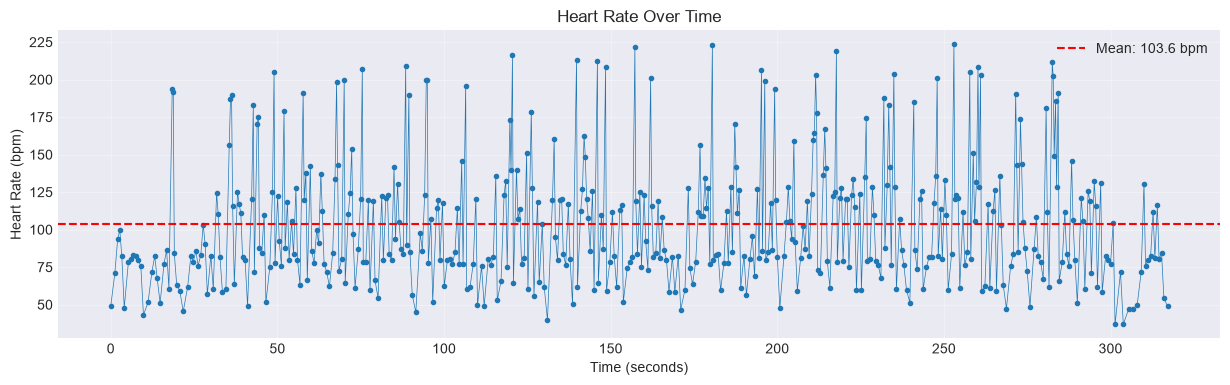

In [7]:
# Explore heart rate from systolic peaks
peaks = phys_data['systolic_peaks']['timestamps']
heart_rate = calculate_heart_rate_from_peaks(peaks, output_unit='bpm')

print(f"Heart Rate Statistics:")
print(f"  Mean: {heart_rate.mean():.1f} bpm")
print(f"  Std: {heart_rate.std():.1f} bpm")
print(f"  Min: {heart_rate.min():.1f} bpm")
print(f"  Max: {heart_rate.max():.1f} bpm")

# Plot heart rate over time
peak_times = (peaks[:-1] - peaks[0]) / 1e9  # Convert to seconds

plt.figure(figsize=(15, 4))
plt.plot(peak_times, heart_rate, marker='o', markersize=3, linestyle='-', linewidth=0.5)
plt.axhline(heart_rate.mean(), color='red', linestyle='--', label=f'Mean: {heart_rate.mean():.1f} bpm')
plt.xlabel('Time (seconds)')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

EDA (Electrodermal Activity) - 1-1-p1_1749054075.avro:
  Sampling frequency: 4.00 Hz
  Number of samples: 7236
  Raw range: 0.26 - 13.62 µS
  Filtered range: 0.33 - 13.60 µS


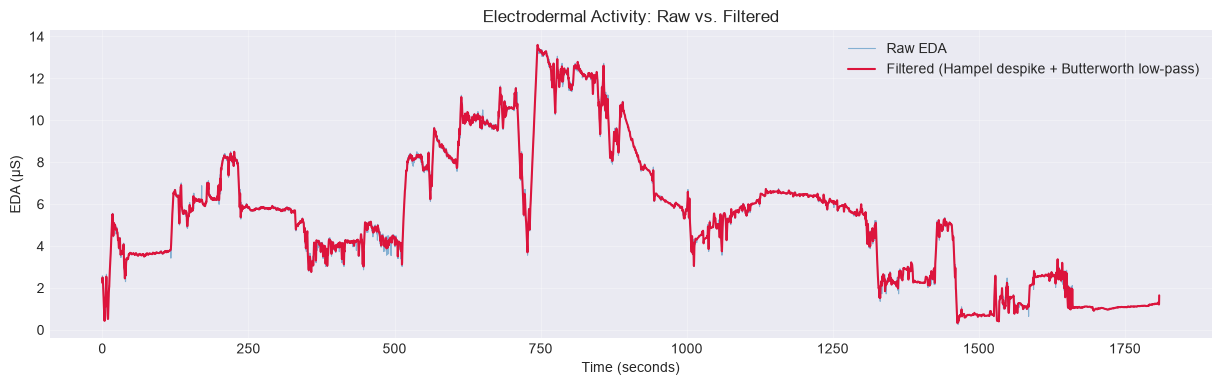

In [ ]:
# Explore EDA data
#
# Applied preprocessing pipeline used in geofatigue.features.eda (Hampel despiking +
# zero-phase Butterworth low-pass).
from geofatigue.features.eda import filter_eda_signal

eda_file = avro_files[7]
eda = load_avro_physiological_data(eda_file)['eda']

eda_values = eda['values'].astype(float)
eda_fs = eda['sampling_frequency']
eda_filtered = filter_eda_signal(eda_values, fs=eda_fs)

print(f"EDA (Electrodermal Activity) - {eda_file.name}:")
print(f"  Sampling frequency: {eda_fs:.2f} Hz")
print(f"  Number of samples: {len(eda_values)}")
print(f"  Raw range: {eda_values.min():.2f} - {eda_values.max():.2f} µS")
print(f"  Filtered range: {eda_filtered.min():.2f} - {eda_filtered.max():.2f} µS")

# Plot raw EDA overlaid with the filtered (Hampel + Butterworth low-pass) signal
time_eda = (eda['timestamps'] - eda['timestamps'][0]) / 1e6  # Convert to seconds

plt.figure(figsize=(15, 4))
plt.plot(time_eda, eda_values, linewidth=0.8, alpha=0.5, label='Raw EDA')
plt.plot(time_eda, eda_filtered, linewidth=1.5, color='crimson',
         label='Filtered (Hampel despike + Butterworth low-pass)')
plt.xlabel('Time (seconds)')
plt.ylabel('EDA (µS)')
plt.title('Electrodermal Activity: Raw vs. Filtered')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Loading Contextual Sensing Data

Load smartphone sensor data collected during the tasks.

In [9]:
CONTEXTUAL_DATA_PATH = os.environ.get('CONTEXTUAL_DATA_PATH')
if not CONTEXTUAL_DATA_PATH:
    raise EnvironmentError("CONTEXTUAL_DATA_PATH not set — copy .env.template to .env and fill in your paths")

contextual_file = f'{CONTEXTUAL_DATA_PATH}/p1-flat_ground.csv'

contextual_data = load_contextual_sensing_data(contextual_file)

print(f"Contextual Sensing Data:")
print(f"  Number of samples: {len(contextual_data)}")
print(f"  Duration: {(contextual_data.index[-1] - contextual_data.index[0]).total_seconds():.1f} seconds")
print(f"  Sampling rate: {len(contextual_data) / (contextual_data.index[-1] - contextual_data.index[0]).total_seconds():.1f} Hz")
print(f"\nAvailable sensors:")
print(contextual_data.columns.tolist())

Contextual Sensing Data:
  Number of samples: 124459
  Duration: 1252.5 seconds
  Sampling rate: 99.4 Hz

Available sensors:
['gFx', 'gFy', 'gFz', 'ax', 'ay', 'az', 'wx', 'wy', 'wz', 'P(Pa)', 'Bx(µT)', 'By(µT)', 'Bz(µT)', 'latitude', 'longitude', 'altitude', 'speed', 'yaw', 'pitch', 'roll', 'dB']


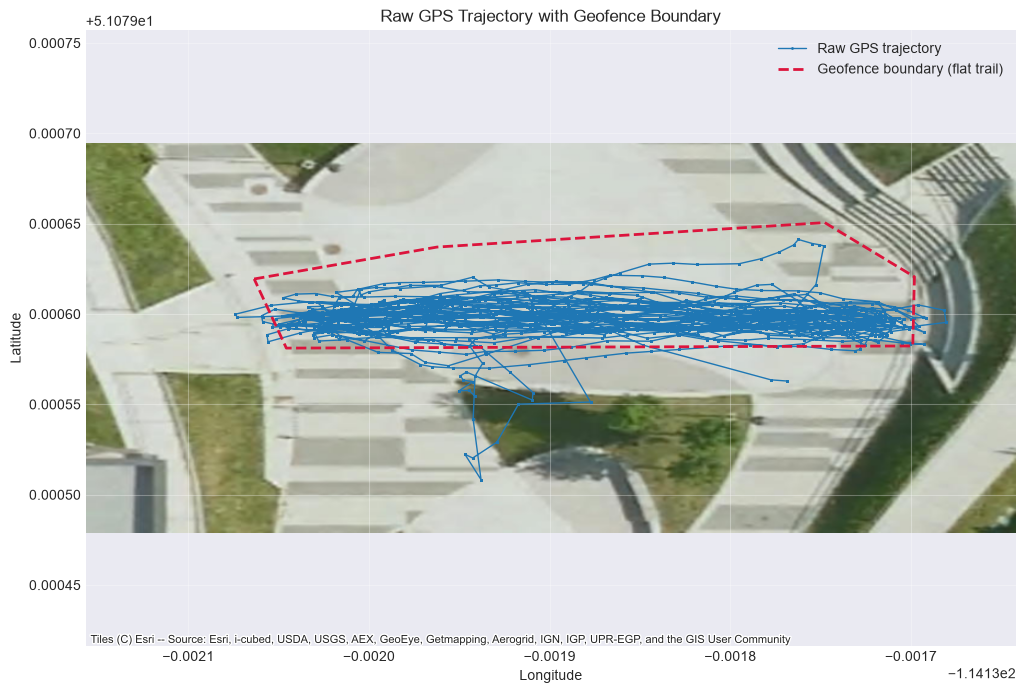

Raw GPS Trajectory:
  Lat range: 51.079508 to 51.079641
  Lon range: -114.132074 to -114.131681
  Altitude range: 1113.07 to 1129.50 m


In [ ]:
# Extract and plot GPS trajectory
gps = extract_gps_trajectory(contextual_data)

# Load the flat-trail geofence zone so its boundary can be drawn alongside the
# trajectory ('p1-flat_ground.csv' is the flat_trail task).
SPATIAL_DATA_PATH = os.environ.get('SPATIAL_DATA_PATH')
if not SPATIAL_DATA_PATH:
    raise EnvironmentError("SPATIAL_DATA_PATH not set — copy .env.template to .env and fill in your paths")

flat_trail_layout = load_all_spatial_layouts(SPATIAL_DATA_PATH)['flat_trail']
flat_trail_zone = flat_trail_layout[flat_trail_layout.geometry.geom_type == 'Polygon']

import contextily as cx

fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(gps['longitude'], gps['latitude'], linewidth=1, marker='.', markersize=2, label='Raw GPS trajectory')
flat_trail_zone.boundary.plot(ax=ax, color='crimson', linewidth=2, linestyle='--', label='Geofence boundary (flat trail)')
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.Esri.WorldImagery)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Raw GPS Trajectory with Geofence Boundary')
ax.grid(True, alpha=0.3)
ax.axis('equal')
ax.legend()
plt.show()

print(f"Raw GPS Trajectory:")
print(f"  Lat range: {gps['latitude'].min():.6f} to {gps['latitude'].max():.6f}")
print(f"  Lon range: {gps['longitude'].min():.6f} to {gps['longitude'].max():.6f}")
print(f"  Altitude range: {gps['altitude'].min():.2f} to {gps['altitude'].max():.2f} m")

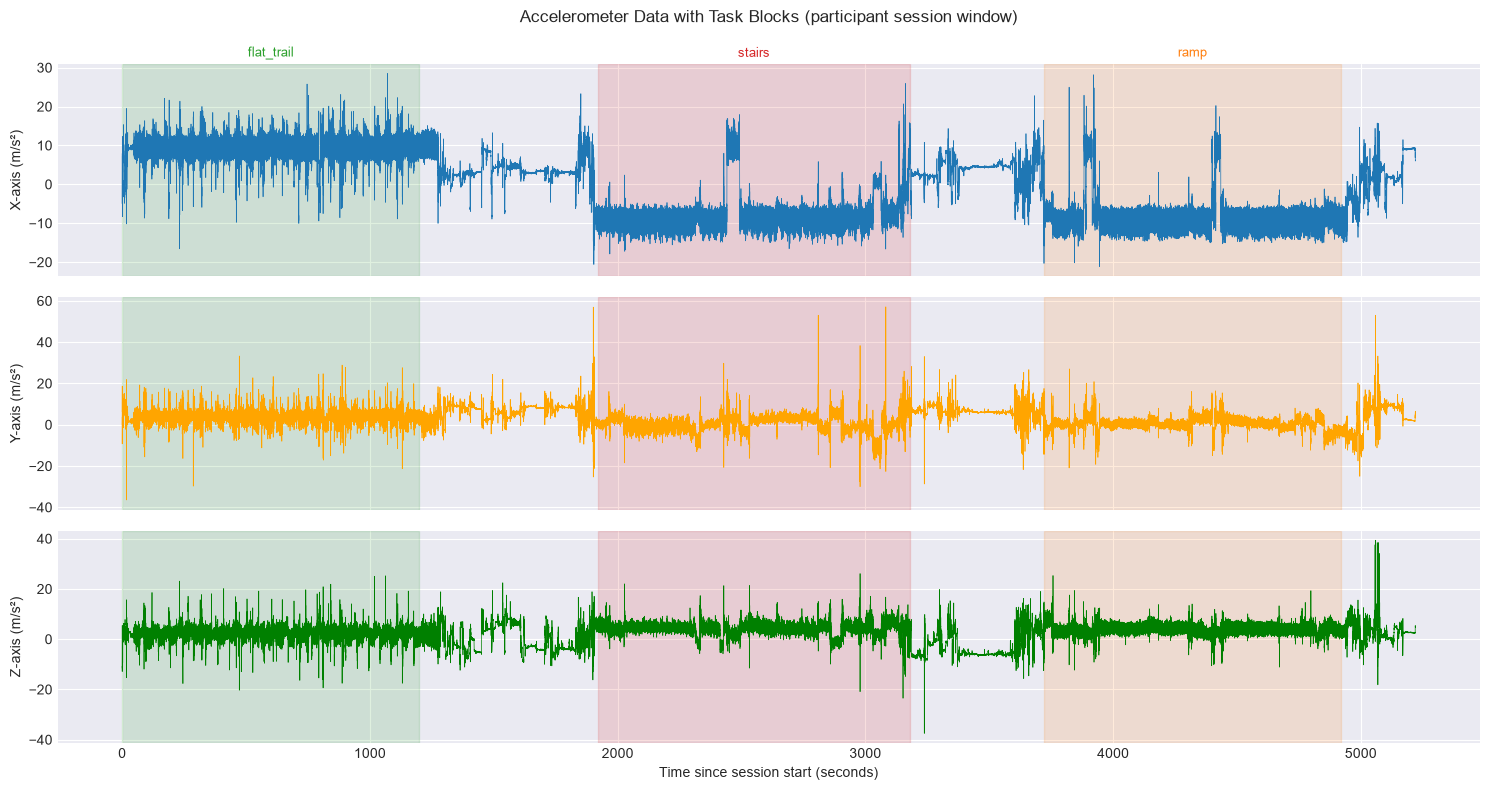

In [ ]:
# Plot session-trimmed accelerometer data (m/s²) captured from the watch with task blocks
#
# Reuses acc_x_g/acc_y_g/acc_z_g, acc_timestamps, time_acc, session and
# session_start_us computed two cells above -- the accelerometer signal
# merged across every AVRO file for the participant and already trimmed to
# the session window. Converts g -> m/s^2 and overlays each task's time
# span as a shaded, labeled block.
GRAVITY_MS2 = 9.80665  # standard gravity, m/s^2 per g
acc_x_ms2 = acc_x_g * GRAVITY_MS2
acc_y_ms2 = acc_y_g * GRAVITY_MS2
acc_z_ms2 = acc_z_g * GRAVITY_MS2

task_colors = {'flat_trail': 'tab:green', 'stairs': 'tab:red', 'ramp': 'tab:orange'}

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

axes[0].plot(time_acc, acc_x_ms2, linewidth=0.5)
axes[0].set_ylabel('X-axis (m/s²)')
axes[0].set_title('Accelerometer Data with Task Blocks (participant session window)', pad=30)

axes[1].plot(time_acc, acc_y_ms2, linewidth=0.5, color='orange')
axes[1].set_ylabel('Y-axis (m/s²)')

axes[2].plot(time_acc, acc_z_ms2, linewidth=0.5, color='green')
axes[2].set_ylabel('Z-axis (m/s²)')
axes[2].set_xlabel('Time since session start (seconds)')

for task in session['tasks']:
    task_start_s = (pd.Timestamp(task['start_time']).value // 1_000 - session_start_us) / 1e6
    task_end_s = (pd.Timestamp(task['end_time']).value // 1_000 - session_start_us) / 1e6
    color = task_colors.get(task['label'], 'gray')

    for ax in axes:
        ax.axvspan(task_start_s, task_end_s, color=color, alpha=0.15)

    axes[0].annotate(
        task['label'],
        xy=((task_start_s + task_end_s) / 2, 1.02),
        xycoords=('data', 'axes fraction'),
        ha='center', va='bottom', fontsize=9, color=color,
    )

plt.tight_layout()
plt.show()

## 4. Loading Spatial Layout

Load the GeoJSON files defining the experiment site boundaries.

In [13]:
# Load spatial layouts (update path)
SPATIAL_DATA_PATH = os.environ.get('SPATIAL_DATA_PATH')
if not SPATIAL_DATA_PATH:
    raise EnvironmentError("SPATIAL_DATA_PATH not set — copy .env.template to .env and fill in your paths")

layouts = load_all_spatial_layouts(SPATIAL_DATA_PATH)

print(f"Loaded spatial layouts:")
for zone_name, gdf in layouts.items():
    print(f"  {zone_name}: {len(gdf)} feature(s)")

Loaded spatial layouts:
  resting_area: 1 feature(s)
  flat_trail: 2 feature(s)
  stairs: 2 feature(s)
  ramp: 2 feature(s)


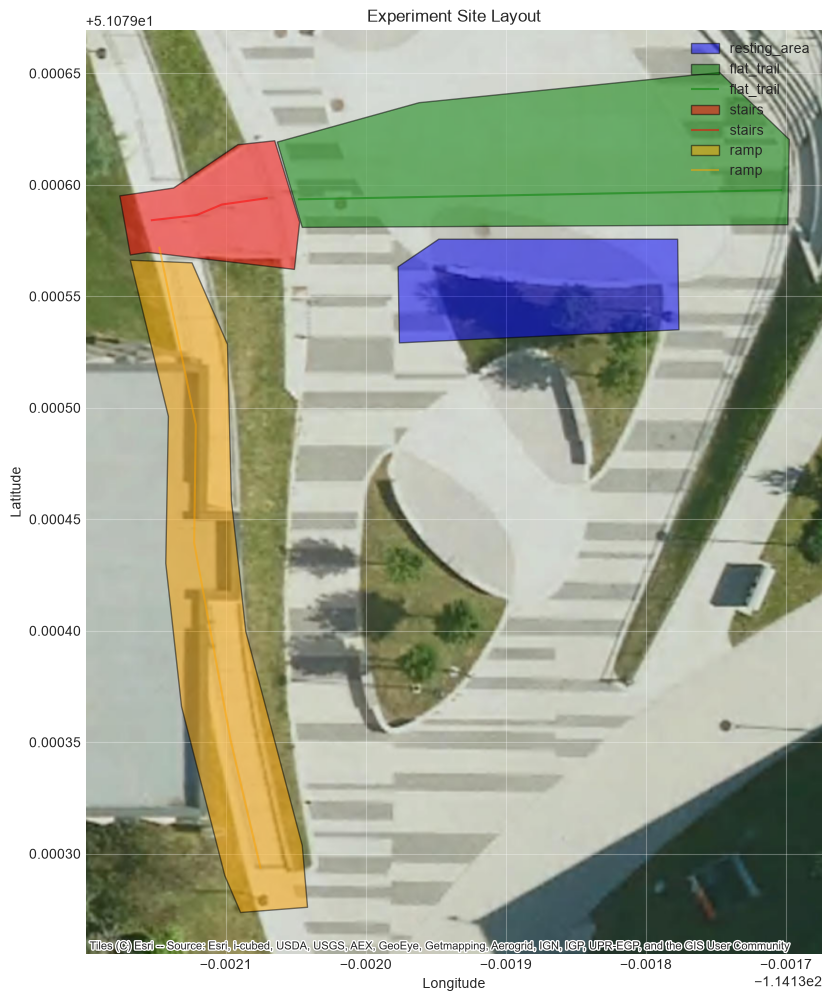

In [14]:
# Plot all zones
import contextily as cx

fig, ax = plt.subplots(figsize=(12, 12))

colors = {'resting_area': 'blue', 'flat_trail': 'green', 'stairs': 'red', 'ramp': 'orange'}

for zone_name, gdf in layouts.items():
    gdf.plot(ax=ax, color=colors.get(zone_name, 'gray'), alpha=0.5, edgecolor='black', label=zone_name)

# Overlay GPS trajectory if available
# ax.plot(gps['longitude'], gps['latitude'], 'k-', linewidth=1, alpha=0.7, label='GPS trajectory')

cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.Esri.WorldImagery)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Experiment Site Layout')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

In [15]:
# Identify location for sample GPS points
sample_points = [
    (-114.13188, 51.07955),  # Should be in resting area
    (-114.13188, 51.07960),  # Should be on flat trail
]

for point in sample_points:
    location = identify_participant_location(point, layouts)
    print(f"Point {point} is in: {location}")

Point (-114.13188, 51.07955) is in: resting_area
Point (-114.13188, 51.0796) is in: flat_trail


## Next Steps

This notebook demonstrated the basic functionality of the GeoFatigue package: loading metadata,
physiological (AVRO) data, contextual smartphone sensing data, and spatial zone layouts.

For more advanced usage, see the rest of the `geofatigue` package:

1. **Spatial-physiology joins**: `geofatigue.loaders.spatial_physiology` (`load_zone_polygons`,
   `load_zone_centerlines`, `build_spatial_biomarker_records`) joins EDA/pulse-rate readings to
   GPS fixes and experiment-site zones.
2. **Lap segmentation & trajectories**: `geofatigue.loaders.lap_trajectory` and
   `geofatigue.features.lap_segmentation` map-match GPS traces to a task's centerline and split
   them into completed laps.
3. **Feature extraction**: `geofatigue.features.biomarker_baseline` computes per-session
   baseline-z-scored EDA/pulse-rate; `geofatigue.features.lap_profile` resamples each lap onto a
   shared 0-100% position grid.
4. **Filtering**: `geofatigue.filters.signal_filter` for cleaning raw sensor signals.
5. **Figures**: `geofatigue.figures` exposes `plot_elevation_physiology_composite` (Figure 6) and
   `plot_spatial_physiology_heatmap` (Figure 7) from the paper. Regenerate both with:

   ```bash
   python scripts/generate_figures.py
   ```

   See the [README](../README.md#regenerating-figures-6-and-7) for CLI options.